##### The idea of this notebook is to intersect the gene TSSs obtained from DeSeq2 to the chromatin loop anchors and make sense of the biological context of the project

In [1]:
# load both bed files

# pandas intersect (with slop?)

#

In [2]:
import pandas as pd
from pybedtools import BedTool

In [3]:
# All the file loading
# Load TSS
tss_up = BedTool("/usr/users/papantonis1/aman/rnaseq_data/mega_upregulated_TSS.bed")
tss_down = BedTool("/usr/users/papantonis1/aman/rnaseq_data/mega_downregulated_TSS.bed")
# loops -mega ctrl + cpi
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/merged_loops.csv", sep=",")
#loops_short = loops[['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']]
loops = pd.DataFrame(loops)
# splitting loops to their anchors
anchor1 = BedTool.from_dataframe(loops[['chr1', 'start1', 'end1']])
anchor2 = BedTool.from_dataframe(loops[['chr2', 'start2', 'end2']])

In [4]:
loops

,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2
0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,0.000000,0.000000,shared,90000,0,NaN,NaN
1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,0.000000,0.000000,shared,180000,1,NaN,NaN
2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,0.000000,0.000000,shared,140000,2,NaN,NaN
3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared,125000,3,NaN,NaN
4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared,50000,4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,0.061177,0.061177,Mutant loop,345000,32272,stable,stable
32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,-0.570544,-0.570544,Mutant loop,310000,32273,stable,stable
32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,0.005836,0.005836,Mutant loop,430000,32274,stable,stable
32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,0.502513,0.502513,Mutant loop,230000,32275,stable,stable


In [5]:
# Extend TSS regions for somewhat good intersection
tss_up_slop = tss_up.slop(b=500, genome='hg38')
tss_down_slop = tss_down.slop(b=500, genome='hg38')

In [6]:
tss_df = tss_up.to_dataframe(names=["chrom", "start", "end", "gene_id", "score", "strand"])
print(tss_df.duplicated().sum())  # total row duplicates
print(tss_df.duplicated(subset=["gene_id"]).sum())  # gene-level duplicates

0
0


In [7]:
len(tss_df)

190

In [8]:
anchor_df = anchor1.to_dataframe(names=["chrom", "start", "end"])
print(anchor_df.duplicated().sum())

8228


In [9]:
anchor_df = anchor2.to_dataframe(names=["chrom", "start", "end"])
print(anchor_df.duplicated().sum())

8555


###### Here the duplicates are (possibly) due to the fact that same anchor can be shared by different distinct loops

In [10]:
tss_df = tss_down.to_dataframe(names=["chrom", "start", "end", "gene_id", "score", "strand"])
print(tss_df.duplicated().sum())  # total row duplicates
print(tss_df.duplicated(subset=["gene_id"]).sum())  # gene-level duplicates

0
0


In [11]:
# tss overlsp with anchor 1 & 2

In [12]:
# function # wa, wb - true. filt. later
def intersect_tss(tss_bed, anchor_bed, num_of_anchor, deg_label):
    df = tss_bed.intersect(anchor_bed, wa=True, wb=True).to_dataframe(names=[
    'tss_chr', 'tss_start', 'tss_end', 'gene_id', 'score', 'strand',
    'anchor_chr', 'anchor_start', 'anchor_end'
    ])
    df['tss_anchor'] = num_of_anchor
    df['deg_class'] = deg_label
    print(df.duplicated().sum())
    print(df.duplicated(subset=["gene_id", "anchor_start", "anchor_end"]).sum())

    return df

# todo: check tss_chr == anchor_chr

In [13]:
up1 = intersect_tss(tss_up_slop, anchor1, 1, 'upregulated_a1')
up2 = intersect_tss(tss_up_slop, anchor2, 2, 'upregulated_a2')
down1 = intersect_tss(tss_down_slop, anchor1, 1, 'downregulated_a1')
down2 = intersect_tss(tss_down_slop, anchor2, 2, 'downregulated_a2')

8
8
4
4
0
0
4
4


In [14]:
all = [up1, up2, down1, down2]
for deg_condition in all:
    print(len(deg_condition))

33
21
7
12


In [15]:
#combine into a single df
tss_anchors_updown = pd.concat([up1, up2, down1, down2], ignore_index=True)
tss_anchors_updown

,tss_chr,tss_start,tss_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,deg_class
0,chr19,41708084,41709085,1048,0,+,chr19,41705000,41710000,1,upregulated_a1
1,chr19,41708084,41709085,1048,0,+,chr19,41705000,41710000,1,upregulated_a1
2,chr17,45147974,45148975,10614,0,+,chr17,45145000,45150000,1,upregulated_a1
3,chr8,27614199,27615200,1191,0,-,chr8,27610000,27615000,1,upregulated_a1
4,chr8,27614199,27615200,1191,0,-,chr8,27610000,27615000,1,upregulated_a1
...,...,...,...,...,...,...,...,...,...,...,...
68,chr22,40346028,40347029,27352,0,+,chr22,40342500,40347500,2,downregulated_a2
69,chr4,1345190,1346191,57654,0,+,chr4,1342500,1347500,2,downregulated_a2
70,chr4,1345190,1346191,57654,0,+,chr4,1342500,1347500,2,downregulated_a2
71,chr10,58512371,58513372,80114,0,+,chr10,58512500,58517500,2,downregulated_a2


In [16]:
tss_anchors_updown = tss_anchors_updown.drop_duplicates(ignore_index=True)
len(tss_anchors_updown)

57

In [17]:
# drop score, strand
#tss_anchors_updown.drop(["score", "strand"], axis=1)


In [18]:
tss_anchors_updown

,tss_chr,tss_start,tss_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,deg_class
0,chr19,41708084,41709085,1048,0,+,chr19,41705000,41710000,1,upregulated_a1
1,chr17,45147974,45148975,10614,0,+,chr17,45145000,45150000,1,upregulated_a1
2,chr8,27614199,27615200,1191,0,-,chr8,27610000,27615000,1,upregulated_a1
3,chr8,27614199,27615200,1191,0,-,chr8,27612500,27617500,1,upregulated_a1
4,chr11,6618947,6619948,1200,0,-,chr11,6615000,6620000,1,upregulated_a1
5,chr22,41699002,41700003,150365,0,+,chr22,41700000,41705000,1,upregulated_a1
6,chr11,1764072,1765073,1509,0,-,chr11,1760000,1765000,1,upregulated_a1
7,chr11,1764072,1765073,1509,0,-,chr11,1765000,1770000,1,upregulated_a1
8,chr12,111753389,111754390,217,0,+,chr12,111750000,111755000,1,upregulated_a1
9,chr4,186726221,186727222,2195,0,-,chr4,186722500,186727500,1,upregulated_a1


In [19]:
#This is a check to make sure that my merged_loop list didn't have duplicates. big scare moment it was. But gave 0 duplicates--yay! I used this file for XGBoost model
cols = [
    "chr1", "start1", "end1",
    "chr2", "start2", "end2",
    "name", "score", "strand1", "strand2"
]  # adjust if fewer or more columns
df = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/merged_loops.csv", sep="\t", header=None, names=cols)
print(df.duplicated().sum())  # full row dupes
print(df.duplicated(subset=["chr1", "start1", "end1", "chr2", "start2", "end2"]).sum())  # loop duplicates

0
0


In [20]:
# next to deal with the non overlapping anchor at the distal end

In [21]:
# Match to left side of loop (chr1/start1/end1)
match_chr1 = tss_anchors_updown.merge(
    loops,
    left_on=["anchor_chr", "anchor_start", "anchor_end"],
    right_on=["chr1", "start1", "end1"],
    how="inner"
)
match_chr1["distal_chr"] = match_chr1["chr2"]
match_chr1["distal_start"] = match_chr1["start2"]
match_chr1["distal_end"] = match_chr1["end2"]

# Match to right side of loop (chr2/start2/end2)
match_chr2 = tss_anchors_updown.merge(
    loops,
    left_on=["anchor_chr", "anchor_start", "anchor_end"],
    right_on=["chr2", "start2", "end2"],
    how="inner"
)
match_chr2["distal_chr"] = match_chr2["chr1"]
match_chr2["distal_start"] = match_chr2["start1"]
match_chr2["distal_end"] = match_chr2["end1"]

# Combine both matches
final_matched_loops = pd.concat([match_chr1, match_chr2], ignore_index=True)

# Keep shortest loop per TSS-anchor to prevent duplicates
final_matched_loops = final_matched_loops.sort_values("distance").drop_duplicates(
    subset=["gene_id", "anchor_chr", "anchor_start", "anchor_end"],
    keep="first",
    ignore_index=True
)

# Output
final_matched_loops


,tss_chr,tss_start,tss_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,...,log2FC,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2,distal_chr,distal_start,distal_end
0,chr16,69754425,69755426,28987,0,-,chr16,69750000,69755000,2,...,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,chr16,69715000,69720000
1,chr19,41708084,41709085,1048,0,+,chr19,41705000,41710000,1,...,-0.380497,-0.380497,shared,40000,3210,stable,stable,chr19,41745000,41750000
2,chr3,157128094,157129095,339894,0,-,chr3,157125000,157130000,2,...,-0.213638,-0.213638,shared,40000,4724,stable,stable,chr3,157085000,157090000
3,chr10,119650879,119651880,9531,0,+,chr10,119650000,119655000,2,...,-0.257207,-0.257207,Control loop,40000,8493,stable,stable,chr10,119610000,119615000
4,chr17,45147974,45148975,10614,0,+,chr17,45145000,45150000,1,...,0.035210,0.035210,shared,50000,2816,stable,stable,chr17,45195000,45200000
5,chr2,70086976,70087977,5093,0,+,chr2,70085000,70090000,1,...,-0.082826,-0.082826,shared,50000,3484,stable,stable,chr2,70135000,70140000
6,chr16,69754425,69755426,28987,0,-,chr16,69755000,69760000,2,...,-0.349063,-0.349063,Control loop,50000,10098,stable,stable,chr16,69705000,69710000
7,chr11,6618947,6619948,1200,0,-,chr11,6615000,6620000,1,...,-0.271396,-0.271396,Control loop,55000,8536,stable,stable,chr11,6670000,6675000
8,chr11,130067646,130068647,334,0,+,chr11,130065000,130070000,2,...,-0.200329,-0.200329,shared,60000,1493,stable,stable,chr11,130005000,130010000
9,chr12,111753389,111754390,217,0,+,chr12,111750000,111755000,1,...,-0.111473,-0.111473,shared,60000,1841,stable,stable,chr12,111810000,111815000


In [22]:
len(final_matched_loops)

56

In [23]:
print(final_matched_loops.columns.tolist())


['tss_chr', 'tss_start', 'tss_end', 'gene_id', 'score', 'strand', 'anchor_chr', 'anchor_start', 'anchor_end', 'tss_anchor', 'deg_class', 'chr1', 'start1', 'end1', 'chr2', 'start2', 'end2', 'status', 'ctrl_signal', 'rbp1_signal', 'log2FC', 'log2FC_clipped', 'condition', 'distance', 'loop_id', 'comp_switch_A1', 'comp_switch_A2', 'distal_chr', 'distal_start', 'distal_end']


In [24]:
import pandas as pd

# Show all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

# Now display
final_matched_loops[["tss_chr", "tss_start", "tss_end", "distal_chr", "distal_start", "distal_end"]]

,tss_chr,tss_start,tss_end,distal_chr,distal_start,distal_end
0,chr16,69754425,69755426,chr16,69715000,69720000
1,chr19,41708084,41709085,chr19,41745000,41750000
2,chr3,157128094,157129095,chr3,157085000,157090000
3,chr10,119650879,119651880,chr10,119610000,119615000
4,chr17,45147974,45148975,chr17,45195000,45200000
5,chr2,70086976,70087977,chr2,70135000,70140000
6,chr16,69754425,69755426,chr16,69705000,69710000
7,chr11,6618947,6619948,chr11,6670000,6675000
8,chr11,130067646,130068647,chr11,130005000,130010000
9,chr12,111753389,111754390,chr12,111810000,111815000


In [25]:
tss_anchors_updown[["tss_chr", "tss_start", "tss_end"
""]]

,tss_chr,tss_start,tss_end
0,chr19,41708084,41709085
1,chr17,45147974,45148975
2,chr8,27614199,27615200
3,chr8,27614199,27615200
4,chr11,6618947,6619948
5,chr22,41699002,41700003
6,chr11,1764072,1765073
7,chr11,1764072,1765073
8,chr12,111753389,111754390
9,chr4,186726221,186727222


In [26]:
final_matched_loops

,tss_chr,tss_start,tss_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,deg_class,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2,distal_chr,distal_start,distal_end
0,chr16,69754425,69755426,28987,0,-,chr16,69750000,69755000,2,upregulated_a2,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,chr16,69715000,69720000
1,chr19,41708084,41709085,1048,0,+,chr19,41705000,41710000,1,upregulated_a1,chr19,41705000,41710000,chr19,41745000,41750000,shared,0.064997,0.049929,-0.380497,-0.380497,shared,40000,3210,stable,stable,chr19,41745000,41750000
2,chr3,157128094,157129095,339894,0,-,chr3,157125000,157130000,2,upregulated_a2,chr3,157085000,157090000,chr3,157125000,157130000,shared,0.029360,0.025319,-0.213638,-0.213638,shared,40000,4724,stable,stable,chr3,157085000,157090000
3,chr10,119650879,119651880,9531,0,+,chr10,119650000,119655000,2,upregulated_a2,chr10,119610000,119615000,chr10,119650000,119655000,lost,0.023680,0.019813,-0.257207,-0.257207,Control loop,40000,8493,stable,stable,chr10,119610000,119615000
4,chr17,45147974,45148975,10614,0,+,chr17,45145000,45150000,1,upregulated_a1,chr17,45145000,45150000,chr17,45195000,45200000,shared,0.053648,0.054974,0.035210,0.035210,shared,50000,2816,stable,stable,chr17,45195000,45200000
5,chr2,70086976,70087977,5093,0,+,chr2,70085000,70090000,1,upregulated_a1,chr2,70085000,70090000,chr2,70135000,70140000,shared,0.037640,0.035540,-0.082826,-0.082826,shared,50000,3484,stable,stable,chr2,70135000,70140000
6,chr16,69754425,69755426,28987,0,-,chr16,69755000,69760000,2,upregulated_a2,chr16,69705000,69710000,chr16,69755000,69760000,lost,0.032249,0.025319,-0.349063,-0.349063,Control loop,50000,10098,stable,stable,chr16,69705000,69710000
7,chr11,6618947,6619948,1200,0,-,chr11,6615000,6620000,1,upregulated_a1,chr11,6615000,6620000,chr11,6670000,6675000,lost,0.016389,0.013579,-0.271396,-0.271396,Control loop,55000,8536,stable,stable,chr11,6670000,6675000
8,chr11,130067646,130068647,334,0,+,chr11,130065000,130070000,2,upregulated_a2,chr11,130005000,130010000,chr11,130065000,130070000,shared,0.026111,0.022726,-0.200329,-0.200329,shared,60000,1493,stable,stable,chr11,130005000,130010000
9,chr12,111753389,111754390,217,0,+,chr12,111750000,111755000,1,upregulated_a1,chr12,111750000,111755000,chr12,111810000,111815000,shared,0.056821,0.052596,-0.111473,-0.111473,shared,60000,1841,stable,stable,chr12,111810000,111815000


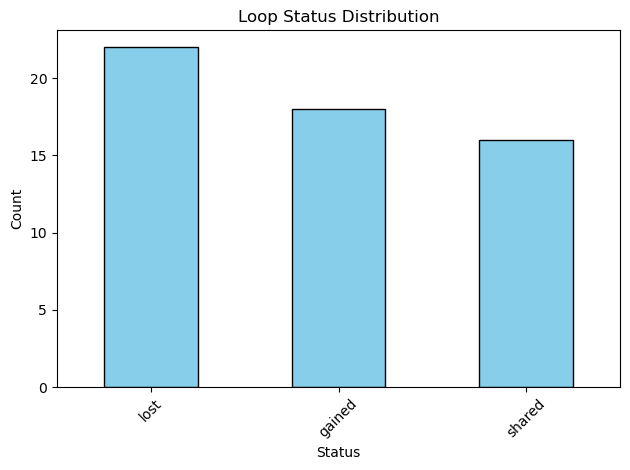

In [27]:
import matplotlib.pyplot as plt

# Count the frequency of each status
status_counts = final_matched_loops['status'].value_counts()

# Plot
status_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Loop Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# if TSS bed file have only 94 rows, how can it have more than 94 matched loops??

In [29]:

from mygene import MyGeneInfo
import pandas as pd

# Initialize MyGeneInfo
mg = MyGeneInfo()

# Get unique Entrez IDs from your DataFrame
entrez_ids = final_matched_loops['gene_id'].unique().tolist()

# Query gene symbols for Entrez IDs (species='human' or 'mouse' as needed)
gene_info = mg.querymany(entrez_ids, scopes='entrezgene', fields='symbol', species='human')

# Convert results to DataFrame
gene_map_df = pd.DataFrame(gene_info)[['query', 'symbol']].dropna()
gene_map_df.columns = ['gene_id', 'gene_symbol']

# Ensure gene_id is same dtype as in original DataFrame
gene_map_df['gene_id'] = gene_map_df['gene_id'].astype(final_matched_loops['gene_id'].dtype)

# Merge gene symbols into your main DataFrame
final_matched_loops = final_matched_loops.merge(gene_map_df, on='gene_id', how='left')


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [30]:
final_matched_loops

,tss_chr,tss_start,tss_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,deg_class,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2,distal_chr,distal_start,distal_end,gene_symbol
0,chr16,69754425,69755426,28987,0,-,chr16,69750000,69755000,2,upregulated_a2,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,chr16,69715000,69720000,NOB1
1,chr19,41708084,41709085,1048,0,+,chr19,41705000,41710000,1,upregulated_a1,chr19,41705000,41710000,chr19,41745000,41750000,shared,0.064997,0.049929,-0.380497,-0.380497,shared,40000,3210,stable,stable,chr19,41745000,41750000,CEACAM5
2,chr3,157128094,157129095,339894,0,-,chr3,157125000,157130000,2,upregulated_a2,chr3,157085000,157090000,chr3,157125000,157130000,shared,0.029360,0.025319,-0.213638,-0.213638,shared,40000,4724,stable,stable,chr3,157085000,157090000,LINC00880
3,chr10,119650879,119651880,9531,0,+,chr10,119650000,119655000,2,upregulated_a2,chr10,119610000,119615000,chr10,119650000,119655000,lost,0.023680,0.019813,-0.257207,-0.257207,Control loop,40000,8493,stable,stable,chr10,119610000,119615000,BAG3
4,chr17,45147974,45148975,10614,0,+,chr17,45145000,45150000,1,upregulated_a1,chr17,45145000,45150000,chr17,45195000,45200000,shared,0.053648,0.054974,0.035210,0.035210,shared,50000,2816,stable,stable,chr17,45195000,45200000,HEXIM1
5,chr2,70086976,70087977,5093,0,+,chr2,70085000,70090000,1,upregulated_a1,chr2,70085000,70090000,chr2,70135000,70140000,shared,0.037640,0.035540,-0.082826,-0.082826,shared,50000,3484,stable,stable,chr2,70135000,70140000,PCBP1
6,chr16,69754425,69755426,28987,0,-,chr16,69755000,69760000,2,upregulated_a2,chr16,69705000,69710000,chr16,69755000,69760000,lost,0.032249,0.025319,-0.349063,-0.349063,Control loop,50000,10098,stable,stable,chr16,69705000,69710000,NOB1
7,chr11,6618947,6619948,1200,0,-,chr11,6615000,6620000,1,upregulated_a1,chr11,6615000,6620000,chr11,6670000,6675000,lost,0.016389,0.013579,-0.271396,-0.271396,Control loop,55000,8536,stable,stable,chr11,6670000,6675000,TPP1
8,chr11,130067646,130068647,334,0,+,chr11,130065000,130070000,2,upregulated_a2,chr11,130005000,130010000,chr11,130065000,130070000,shared,0.026111,0.022726,-0.200329,-0.200329,shared,60000,1493,stable,stable,chr11,130005000,130010000,APLP2
9,chr12,111753389,111754390,217,0,+,chr12,111750000,111755000,1,upregulated_a1,chr12,111750000,111755000,chr12,111810000,111815000,shared,0.056821,0.052596,-0.111473,-0.111473,shared,60000,1841,stable,stable,chr12,111810000,111815000,ALDH2


In [31]:
final_matched_loops["gene_symbol"]

0                NOB1
1             CEACAM5
2           LINC00880
3                BAG3
4              HEXIM1
5               PCBP1
6                NOB1
7                TPP1
8               APLP2
9               ALDH2
10               CTSD
11               CTSD
12            CCDC124
13               IL6R
14             LRRC45
15           CDK5RAP3
16              CCNE2
17             HDAC10
18              UVSSA
19               FAT1
20                MMD
21            SLC30A1
22           CEACAM19
23              PTPRF
24              PODXL
25               INSR
26            ZFP36L2
27              CDCA8
28              BICC1
29              CDCP1
30               MEI1
31              SORT1
32                CLU
33    MMP24-AS1-EDEM2
34                CLU
35               GAR1
36              PCBP1
37              FHOD1
38            SLC17A8
39              EFNA5
40               FAT1
41           SNORA80B
42              LAMC2
43            BHLHE40
44           APOBEC3F
45        

In [33]:
genestocheck = final_matched_loops["gene_symbol"].dropna().unique().tolist()
genestocheck

['NOB1',
 'CEACAM5',
 'LINC00880',
 'BAG3',
 'HEXIM1',
 'PCBP1',
 'TPP1',
 'APLP2',
 'ALDH2',
 'CTSD',
 'CCDC124',
 'IL6R',
 'LRRC45',
 'CDK5RAP3',
 'CCNE2',
 'HDAC10',
 'UVSSA',
 'FAT1',
 'MMD',
 'SLC30A1',
 'CEACAM19',
 'PTPRF',
 'PODXL',
 'INSR',
 'ZFP36L2',
 'CDCA8',
 'BICC1',
 'CDCP1',
 'MEI1',
 'SORT1',
 'CLU',
 'MMP24-AS1-EDEM2',
 'GAR1',
 'FHOD1',
 'SLC17A8',
 'EFNA5',
 'SNORA80B',
 'LAMC2',
 'BHLHE40',
 'APOBEC3F',
 'CASP6',
 'SGSM3',
 'PARM1',
 'IL17RD',
 'LTBP1',
 'MECOM']

In [32]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')